# Exploratory Data Analysis on 25-year VIX Data
## For Dissertation Topic A

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Data

In [10]:
vix = pd.read_excel(
    '/Users/sebastianprasetyo/Documents/University/KCL/Research Project/Topic Research/Data Gathering/VIX_daily_2000_2026.xlsx',
    skiprows=5 #first five rows are just metadata
)

# rename columns so its more clean
vix.columns = ['Date','VIX','PX_BID']

# drop PX_BID column and empty rows
vix = vix[['Date', 'VIX']]
vix = vix[vix["Date"] != 'Date']
vix = vix.dropna()

# convert data types
vix['Date'] = pd.to_datetime(vix['Date'])
vix['VIX'] = pd.to_numeric(vix['VIX'], errors='coerce')

# sort chronologically
vix = vix.sort_values('Date').reset_index(drop=True)

# confirm changes
print(vix.head())
print(vix.tail())
print(f"\nShape: {vix.shape}")
print(f"Date range: {vix['Date'].min()} to {vix['Date'].max()}")            

        Date    VIX
0 1999-12-31  24.64
1 2000-01-03  24.21
2 2000-01-04  27.01
3 2000-01-05  26.41
4 2000-01-06  25.73
           Date    VIX
6626 2026-03-26  27.44
6627 2026-03-27  31.05
6628 2026-03-30  30.61
6629 2026-03-31  25.25
6630 2026-04-01  24.72

Shape: (6631, 2)
Date range: 1999-12-31 00:00:00 to 2026-04-01 00:00:00


### Descriptive Statistics

In [11]:
print("=" * 40)
print("VIX DESCRIPTIVE STATISTICS")
print("=" * 40)
print(f"Mean:         {vix['VIX'].mean():.2f}")
print(f"Median:       {vix['VIX'].median():.2f}")
print(f"Std Dev:      {vix['VIX'].std():.2f}")
print(f"Min:          {vix['VIX'].min():.2f}")
print(f"Max:          {vix['VIX'].max():.2f}")

VIX DESCRIPTIVE STATISTICS
Mean:         19.84
Median:       17.79
Std Dev:      8.33
Min:          9.14
Max:          82.69


### Percentile Analysis
Identifying where common thresholds (20, 25, 30) sit relative to the full distribution

In [12]:
print("── Percentiles ───────────────────────────────")
for p in [50, 60, 70, 75, 80, 85, 90, 95]:
    val = vix['VIX'].quantile(p/100)
    count = (vix['VIX'] > val).sum()
    pct = count / len(vix) * 100
    print(f"  {p}th percentile: {val:.2f}  →  {count} days above ({pct:.1f}%)")

print("\n── Days above common thresholds ──────────────")
for threshold in [20, 25, 30, 35, 40]:
    count = (vix['VIX'] > threshold).sum()
    pct = count / len(vix) * 100
    print(f"  VIX > {threshold}: {count} days ({pct:.1f}% of sample)")

── Percentiles ───────────────────────────────
  50th percentile: 17.79  →  3315 days above (50.0%)
  60th percentile: 19.66  →  2650 days above (40.0%)
  70th percentile: 21.90  →  1988 days above (30.0%)
  75th percentile: 23.23  →  1658 days above (25.0%)
  80th percentile: 24.76  →  1325 days above (20.0%)
  85th percentile: 26.56  →  995 days above (15.0%)
  90th percentile: 29.55  →  663 days above (10.0%)
  95th percentile: 34.33  →  332 days above (5.0%)

── Days above common thresholds ──────────────
  VIX > 20: 2553 days (38.5% of sample)
  VIX > 25: 1273 days (19.2% of sample)
  VIX > 30: 623 days (9.4% of sample)
  VIX > 35: 312 days (4.7% of sample)
  VIX > 40: 192 days (2.9% of sample)


### Time Series Plot
VIX level over the full sample with candidate threshold overlaid

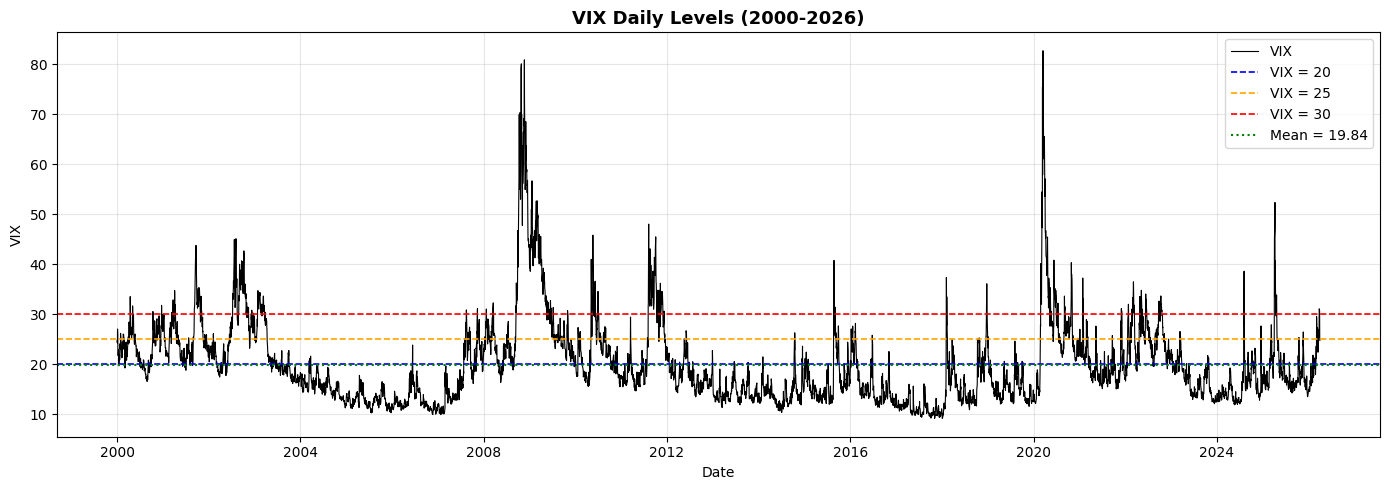

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(vix['Date'], vix['VIX'], color='black', linewidth=0.8, label='VIX')
for threshold, color, style in [(20, 'blue', '--'), (25, 'orange', '--'), (30, 'red', '--')]:
    ax.axhline(y=threshold, color=color, linestyle=style, linewidth=1.2, label=f'VIX = {threshold}')
ax.axhline(y=vix['VIX'].mean(), color='green', linestyle=':', linewidth=1.5, label=f'Mean = {vix["VIX"].mean():.2f}')

ax.set_title('VIX Daily Levels (2000-2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VIX')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vix_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution Histogram
Frequency distribution of VIX levels with candidate thresholds overlaid

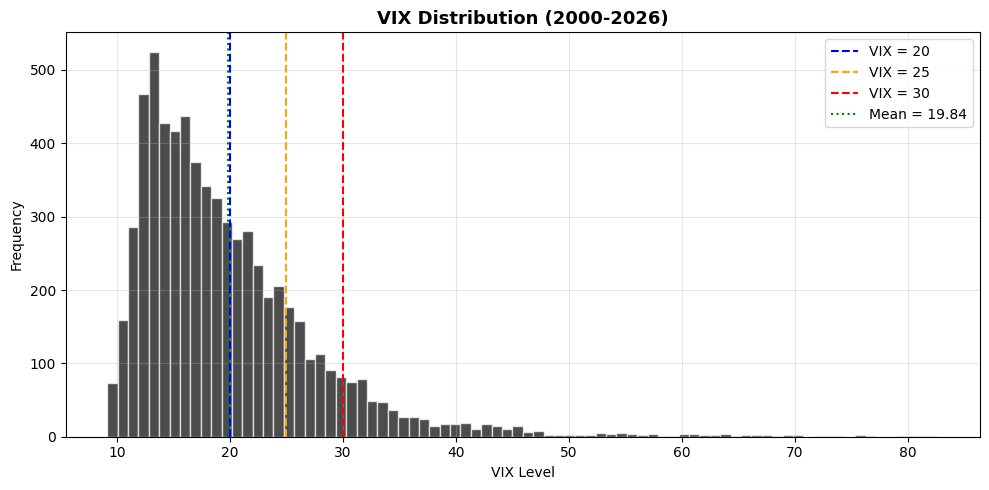

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(vix['VIX'], bins=80, color='black', alpha=0.7, edgecolor='white')
for threshold, color in [(20, 'blue'), (25, 'orange'), (30, 'red')]:
    ax.axvline(x=threshold, color=color, linestyle='--', linewidth=1.5, label=f'VIX = {threshold}')
ax.axvline(x=vix['VIX'].mean(), color='green', linestyle=':', linewidth=1.5, label=f'Mean = {vix["VIX"].mean():.2f}')

ax.set_title('VIX Distribution (2000-2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('VIX Level')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vix_histogram.png', dpi=150, bbox_inches='tight')
plt.show()